In [60]:
import json
import pandas as pd
from pathlib import Path

here = Path.cwd()  # notebook's working dir
print("CWD:", here)

# walk upward until we find a folder that contains "runs/"
repo_root = next(p for p in [here] + list(here.parents) if (p / "runs").exists())

runs_dir = repo_root / "runs"
latest_run_dir = max([d for d in runs_dir.iterdir() if d.is_dir()], key=lambda d: d.stat().st_mtime)

eval_path = latest_run_dir / "eval.json"
print("Using:", eval_path)

with eval_path.open("r", encoding="utf-8") as f:
    eval_info = json.load(f)

df = pd.json_normalize(eval_info)
curve_df = pd.DataFrame(df['components.coverage_curve'][0])
curve_df

CWD: c:\Users\paulr\Desktop\Projects\NLP\godot-issue-triager\src\scripts
Using: c:\Users\paulr\Desktop\Projects\NLP\godot-issue-triager\runs\20260226_212256\eval.json


,threshold,coverage,avg_pred_labels,micro_f1_all,macro_f1_all,hamming_loss_all,micro_f1_covered,macro_f1_covered,hamming_loss_covered
0,0.050,1.000000,15.470718,0.163819,0.146035,0.782803,0.163819,0.146035,0.782803
1,0.053,1.000000,15.091559,0.167557,0.148572,0.761769,0.167557,0.148572,0.761769
2,0.056,1.000000,14.721199,0.171411,0.151323,0.741194,0.171411,0.151323,0.741194
3,0.059,1.000000,14.367061,0.175266,0.154227,0.721520,0.175266,0.154227,0.721520
4,0.062,1.000000,13.996701,0.179487,0.157535,0.700944,0.179487,0.157535,0.700944
...,...,...,...,...,...,...,...,...,...
296,0.938,0.119879,0.125378,0.148283,0.206309,0.071243,0.740201,0.670324,0.036315
297,0.941,0.112180,0.116030,0.137817,0.194928,0.071671,0.732422,0.666618,0.037309
298,0.944,0.104207,0.107231,0.128651,0.183465,0.072007,0.729560,0.666561,0.037819
299,0.947,0.095683,0.098433,0.119375,0.173090,0.072343,0.731207,0.662566,0.037676


In [61]:
rows = []
for task, info in eval_info.items():
    m_all = info.get("metrics_all", {}) or {}
    m_cov = info.get("metrics_at_coverage", {}) or {}
    rows.append({
        "task": task,
        "micro_f1": m_all.get("micro_f1"),
        "macro_f1": m_all.get("macro_f1"),
        "hamming_loss": m_all.get("hamming_loss"),
        "coverage": m_all.get("coverage"),
        "avg_pred_labels": m_all.get("avg_pred_labels"),
        "micro_f1_covered": m_cov.get("micro_f1"),
        "hit@5": info.get("hit_at_5"),
        "recall@5_micro": info.get("recall_at_5_micro"),
    })

metrics_df = pd.DataFrame(rows).set_index("task").sort_index()
metrics_df

,micro_f1,macro_f1,hamming_loss,coverage,avg_pred_labels,micro_f1_covered,hit@5,recall@5_micro
task,,,,,,,,
components,0.672471,0.644507,0.054593,0.930987,1.620016,0.690700,0.966731,0.960558
impact,0.612600,0.588493,0.073550,0.334616,0.381358,0.721535,0.340665,1.000000
issue_type,0.772101,0.332992,0.105788,0.903492,0.945834,0.805624,0.910916,1.000000
platform,0.678144,0.681881,0.023646,0.182018,0.185867,0.798238,0.177344,1.000000


target_cov (eval.json): 0.9309870772614792
star_cov (curve point): 0.9309870772614792
star_threshold (curve point): 0.515


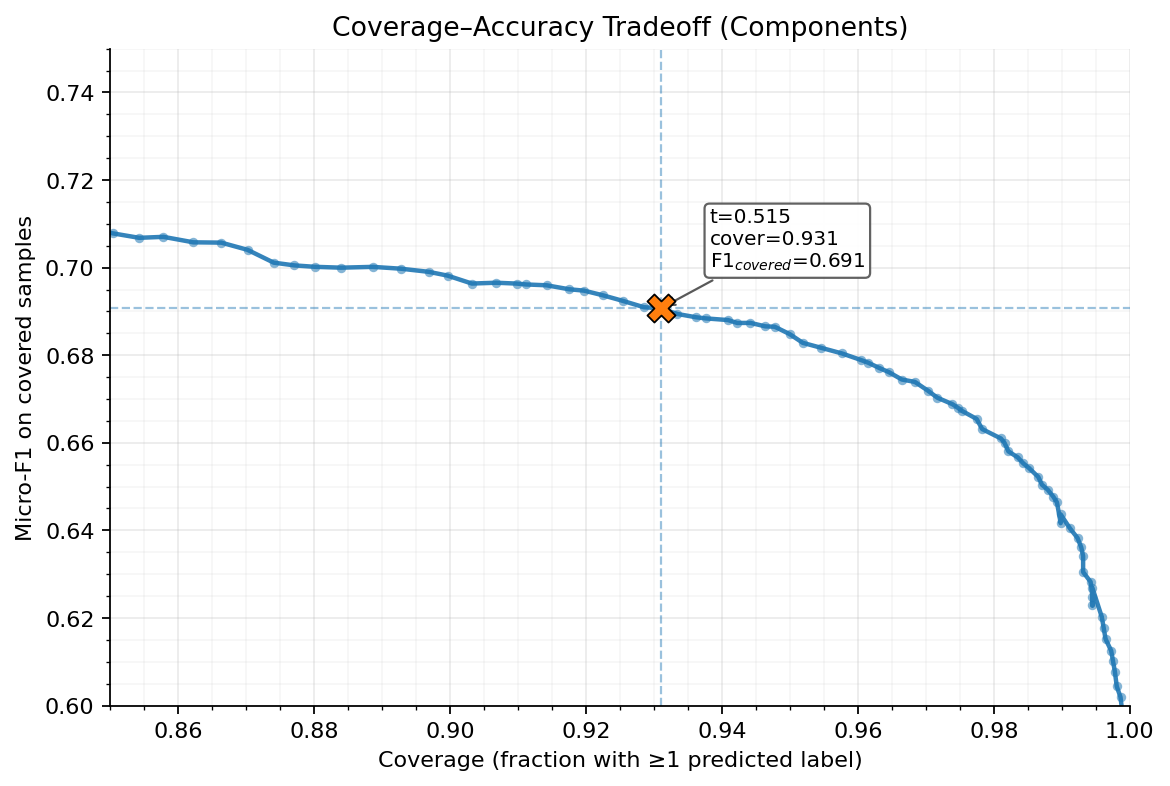

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- sort by x-axis variable (coverage) so the line is monotonic left->right ---
plot_df = curve_df.copy().sort_values("coverage")

# --- tuned operating point (nearest threshold) ---
t_star = 0.516
i_star = (plot_df["threshold"] - t_star).abs().idxmin()
star = plot_df.loc[i_star]

print("target_cov (eval.json):", eval_info["components"]["coverage"])
print("star_cov (curve point):", float(star["coverage"]))
print("star_threshold (curve point):", float(star["threshold"]))

# --- plotting ---
fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=160, constrained_layout=True)

# line (no markers)
ax.plot(
    plot_df["coverage"],
    plot_df["micro_f1_covered"],
    linewidth=2.0,
    alpha=0.9,
)

# subtle points (optional but helps show discretization)
ax.scatter(
    plot_df["coverage"],
    plot_df["micro_f1_covered"],
    s=18,
    alpha=0.55,
    linewidths=0,
)

# tuned point
ax.scatter(
    [star["coverage"]],
    [star["micro_f1_covered"]],
    s=160,
    marker="X",
    zorder=6,
    edgecolor="black",
    linewidth=0.8,
)

# guide lines through tuned point
ax.axvline(star["coverage"], linestyle="--", linewidth=1.0, alpha=0.45)
ax.axhline(star["micro_f1_covered"], linestyle="--", linewidth=1.0, alpha=0.45)

# annotation with a bbox + arrow (prevents text sitting on the curve)
label = (
    f"t={star['threshold']:.3f}\n"
    f"cover={star['coverage']:.3f}\n"
    f"F1$_{{covered}}$={star['micro_f1_covered']:.3f}"
)
ax.annotate(
    label,
    xy=(star["coverage"], star["micro_f1_covered"]),
    xytext=(22, 16),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.35", alpha=0.95),
    arrowprops=dict(arrowstyle="->", lw=1.0, color="0.35"),
)

# axes / styling
ax.set_xlim(0.85, 1.0)
ax.set_ylim(0.60, 0.75)

ax.set_xlabel("Coverage (fraction with ≥1 predicted label)")
ax.set_ylabel("Micro-F1 on covered samples")
ax.set_title("Coverage–Accuracy Tradeoff (Components)")

# cleaner axes + grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.set_major_locator(MaxNLocator(8))
ax.yaxis.set_major_locator(MaxNLocator(8))

ax.grid(True, which="major", alpha=0.25)
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.10)

plt.show()


In [ ]:
import json
import pandas as pd
from pathlib import Path

data_dir = repo_root / "src" / "scripts" / "data_collection" / "data" / "processed"
paths = {
    "train": data_dir / "train.json",
    "val":   data_dir / "val.json",
    "test":  data_dir / "test.json",
}
vocab_path = data_dir / "label_vocab.json"

def load_df(p: Path) -> pd.DataFrame:
    with p.open("r", encoding="utf-8") as f:
        return pd.DataFrame(json.load(f))

dfs = {k: load_df(p) for k, p in paths.items()}

with vocab_path.open("r", encoding="utf-8") as f:
    vocab = json.load(f)

components_vocab = set(vocab.get("components", []))
has_other = "other" in components_vocab

# ---- helpers ----
def date_range(df: pd.DataFrame):
    for col in ["created_at", "createdAt", "created_utc", "created"]:
        if col in df.columns:
            ts = pd.to_datetime(df[col], errors="coerce", utc=True)
            return ts.min(), ts.max(), col
    return None, None, None

def pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def gt_presence_rate(series: pd.Series) -> float:
    """
    Fraction of rows with >=1 ground-truth label.
    Works for list[str], str, or nulls.
    """
    def has_label(x) -> bool:
        if x is None or (isinstance(x, float) and pd.isna(x)):
            return False
        if isinstance(x, list):
            return len(x) > 0
        if isinstance(x, str):
            return len(x.strip()) > 0
        return False  # fallback for unexpected types

    return float(series.apply(has_label).mean())

def avg_label_count(series: pd.Series) -> float:
    """Average number of labels per row (list[str] -> len, str -> 1 if non-empty else 0)."""
    def count(x) -> int:
        if x is None or (isinstance(x, float) and pd.isna(x)):
            return 0
        if isinstance(x, list):
            return len(x)
        if isinstance(x, str):
            return 1 if len(x.strip()) > 0 else 0
        return 0
    return float(series.apply(count).mean())

# ---- dataset/split summary ----
rows = []
for split, df in dfs.items():
    mn, mx, date_col = date_range(df)

    # components column 
    comp_col = pick_col(df, ["topic", "components"])
    plat_col = pick_col(df, ["platform", "platforms", "os"])
    impact_col = pick_col(df, ["impact", "severity", "priority"])
    type_col = pick_col(df, ["issue_type", "type"])

    # components stats
    if comp_col:
        y = df[comp_col].apply(lambda x: x if isinstance(x, list) else [])
        avg_true_components = float(y.apply(len).mean())
        frac_other = float(y.apply(lambda lst: ("other" in lst)).mean()) if has_other else None
    else:
        avg_true_components = None
        frac_other = None

    # platform/impact GT presence (and optional avg counts)
    plat_gt = gt_presence_rate(df[plat_col]) if plat_col else None
    impact_gt = gt_presence_rate(df[impact_col]) if impact_col else None

    rows.append({
        "split": split,
        "n_issues": len(df),
        "date_col": date_col,
        "date_min": None if mn is None else str(mn.date()),
        "date_max": None if mx is None else str(mx.date()),

        # components (primary routing) stats
        "avg_true_components": avg_true_components,
        "frac_issues_with_other": frac_other,

        # NEW: GT presence rates (fractions)
        "platform_gt_rate": plat_gt,
        "impact_gt_rate": impact_gt,

        # Optional extras if you want them:
        # "avg_true_platform": avg_label_count(df[plat_col]) if plat_col else None,
        # "avg_true_impact": avg_label_count(df[impact_col]) if impact_col else None,
        # "issue_type_gt_rate": gt_presence_rate(df[type_col]) if type_col else None,
    })

split_summary = pd.DataFrame(rows)

# Pretty-print as percentages for table
pretty = split_summary.copy()
for c in ["platform_gt_rate", "impact_gt_rate", "frac_issues_with_other"]:
    if c in pretty.columns:
        pretty[c] = pretty[c].apply(lambda v: None if v is None else round(100.0 * v, 1))

pretty

,split,n_issues,date_col,date_min,date_max,avg_true_components,frac_issues_with_other,platform_gt_rate,impact_gt_rate
0,train,12727,created_at,2023-03-27,2025-02-06,1.442602,10.2,15.4,26.8
1,val,1818,created_at,2025-02-06,2025-05-29,1.391639,7.8,19.0,30.1
2,test,3637,created_at,2025-05-29,2026-02-11,1.380258,8.3,17.7,34.1


In [64]:
# ---- component frequency in TRAIN (or overall) ----
train_df = dfs["train"]
y = train_df["topic"].apply(lambda x: x if isinstance(x, list) else [])
freq = y.explode().value_counts(dropna=True)

top10 = freq.head(10).reset_index()
top10.columns = ["component", "count"]

label_vocab_summary = {
    "N_components_in_vocab": len(components_vocab),
    "has_other": has_other,
    "min_support_in_train_for_vocab_labels": int(freq.loc[list(components_vocab)].min()) if len(components_vocab) else None,
}
top10, label_vocab_summary

(   component  count
 0     editor   4075
 1  rendering   1977
 2         3d   1604
 3        gui   1426
 4      other   1296
 5       core   1117
 6   gdscript    991
 7         2d    978
 8  platforms    710
 9  animation    682,
 {'N_components_in_vocab': 18,
  'has_other': True,
  'min_support_in_train_for_vocab_labels': 243})

In [65]:
import json
from pathlib import Path

run_dir = Path(latest_run_dir)  # you already have this
summary_path = run_dir / "schema_validation_summary.json"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
print("valid_rate:", summary["valid_rate"])
print("valid_count:", summary["valid_count"], "/", summary["total"])
print("top_errors (first 5):", summary["top_errors"][:5])

valid_rate: 1.0
valid_count: 3637 / 3637
top_errors (first 5): []


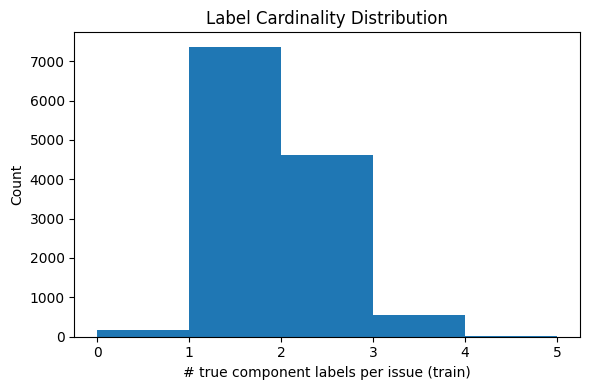

In [66]:
import matplotlib.pyplot as plt

train_y = dfs["train"]["topic"].apply(lambda x: x if isinstance(x, list) else [])
card = train_y.apply(len)

plt.figure(figsize=(6,4))
plt.hist(card, bins=range(0, int(card.max())+2))
plt.xlabel("# true component labels per issue (train)")
plt.ylabel("Count")
plt.title("Label Cardinality Distribution")
plt.tight_layout()
plt.show()

In [ ]:
comp = eval_info["components"]

print("RUN DIR:", latest_run_dir)
print("components top-level coverage:", comp.get("coverage"))

ma = comp.get("metrics_all", {}) or {}
print("components metrics_all coverage:", ma.get("coverage"))
print("components metrics_all micro_f1:", ma.get("micro_f1"))
print("components metrics_all macro_f1:", ma.get("macro_f1"))

print("components keys:", list(comp.keys()))
print("metrics_all keys:", list(ma.keys()))

RUN DIR: c:\Users\paulr\Desktop\Projects\NLP\godot-issue-triager\runs\20260226_212256
components top-level coverage: 0.9309870772614792
components metrics_all coverage: 0.9309870772614792
components metrics_all micro_f1: 0.6724706744868035
components metrics_all macro_f1: 0.6445073558492747
components keys: ['metrics_all', 'metrics_at_coverage', 'hit_at_5', 'recall_at_5_micro', 'coverage', 'avg_pred_labels', 'coverage_curve', 'report']
metrics_all keys: ['micro_f1', 'macro_f1', 'hamming_loss', 'coverage', 'avg_pred_labels']


: 